<a href="https://colab.research.google.com/github/SaniyaIrfan1113/Fabric-defect-detection-using-deep-learning/blob/main/Yolo_v10_92_3_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Sat Mar  1 17:47:36 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   52C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
HOME = os.getcwd()
print(HOME)

/content


## Install YOLOv10

**NOTE:** Currently, YOLOv10 does not have its own PyPI package. Therefore, we need to install the code from the source.

In [ ]:
!pip install -q git+https://github.com/THU-MIG/yolov10.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 104.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 84.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 58.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 96.8 MB/s eta 0:00:00


In [ ]:
!pip install -q supervision roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 181.5/181.5 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.1/83.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 11.5 MB/s eta 0:00:00


## Download pre-trained weights

**NOTE:** YOLOv10 provides weight files pre-trained on the COCO dataset in various sizes. Let's download them.

In [ ]:
!mkdir -p {HOME}/weights
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10n.pt
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10s.pt
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10m.pt
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10b.pt
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10x.pt
!wget -P {HOME}/weights -q https://github.com/THU-MIG/yolov10/releases/download/v1.1/yolov10l.pt
!ls -lh {HOME}/weights

total 408M
-rw-r--r-- 1 root root  80M May 26  2024 yolov10b.pt
-rw-r--r-- 1 root root 100M May 26  2024 yolov10l.pt
-rw-r--r-- 1 root root  64M May 26  2024 yolov10m.pt
-rw-r--r-- 1 root root  11M May 26  2024 yolov10n.pt
-rw-r--r-- 1 root root  32M May 26  2024 yolov10s.pt
-rw-r--r-- 1 root root 123M May 26  2024 yolov10x.pt


## Download dataset from Roboflow Universe

In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="pilo1phCa5MQHOOzhDzc")
project = rf.workspace("saniya-irfan-vtnss").project("my-first-project-7oq45")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...


**NOTE:**
Make sure the last 4 lines of the data.yaml file have the following format:

```
test: ../test/images
train: ../train/images
val: ../valid/images
```

If using a dataset from Roboflow, run the command below. 👇🏻

In [ ]:
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!sed -i '$d' {dataset.location}/data.yaml
!echo -e "test: ../test/images\ntrain: ../train/images\nval: ../valid/images" >> {dataset.location}/data.yaml

## Custom Training

In [ ]:
%cd {HOME}

!yolo task=detect mode=train epochs=80 batch=32 plots=True \
model={HOME}/weights/yolov10n.pt \
data={dataset.location}/data.yaml

/content
/usr/local/lib/python3.11/dist-packages/ultralytics/nn/tasks.py:733: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(file, map_location="cpu")
New h

In [ ]:
!ls {HOME}/runs/detect/train/

args.yaml					    R_curve.png		 val_batch0_labels.jpg
confusion_matrix_normalized.png			    results.csv		 val_batch0_pred.jpg
confusion_matrix.png				    results.png		 val_batch1_labels.jpg
events.out.tfevents.1740851743.f9a74cc8cfb1.2899.0  train_batch0.jpg	 val_batch1_pred.jpg
F1_curve.png					    train_batch1.jpg	 val_batch2_labels.jpg
labels_correlogram.jpg				    train_batch2.jpg	 val_batch2_pred.jpg
labels.jpg					    train_batch3430.jpg  weights
P_curve.png					    train_batch3431.jpg
PR_curve.png					    train_batch3432.jpg


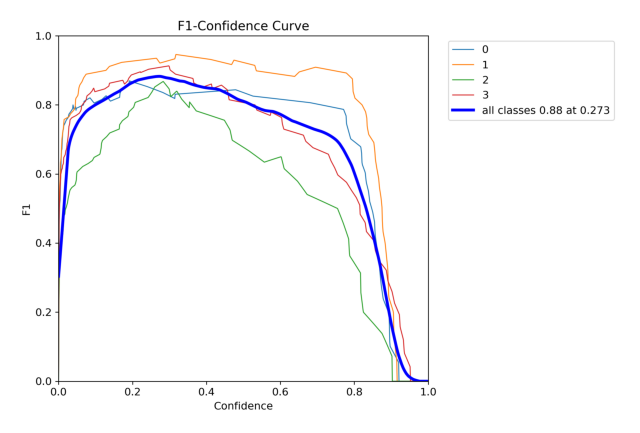

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Path to your image (change this to an actual image from your dataset)
image_path = "/content/runs/detect/train/F1_curve.png"

# Read and display the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB (for correct colors in Matplotlib)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")  # Hide axis
plt.show()


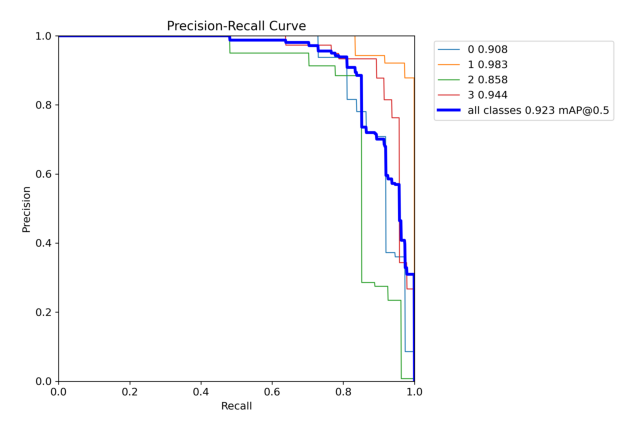

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Path to your image (change this to an actual image from your dataset)
image_path = "/content/runs/detect/train/PR_curve.png"

# Read and display the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB (for correct colors in Matplotlib)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")  # Hide axis
plt.show()


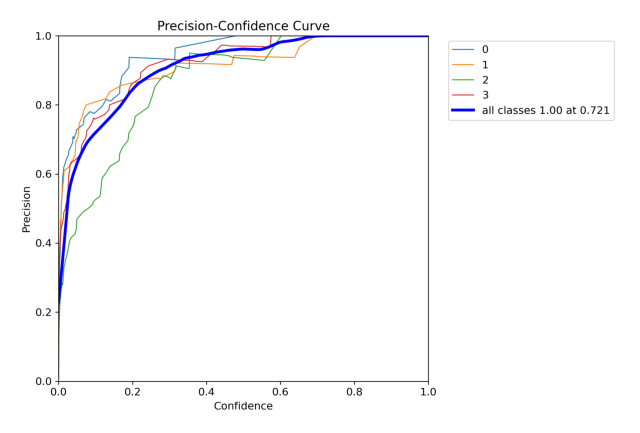

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Path to your image (change this to an actual image from your dataset)
image_path = "/content/runs/detect/train/P_curve.png"

# Read and display the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB (for correct colors in Matplotlib)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")  # Hide axis
plt.show()


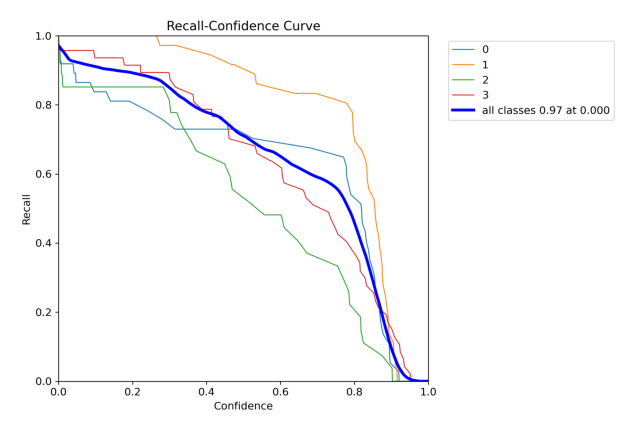

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Path to your image (change this to an actual image from your dataset)
image_path = "/content/runs/detect/train/R_curve.png"

# Read and display the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB (for correct colors in Matplotlib)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")  # Hide axis
plt.show()


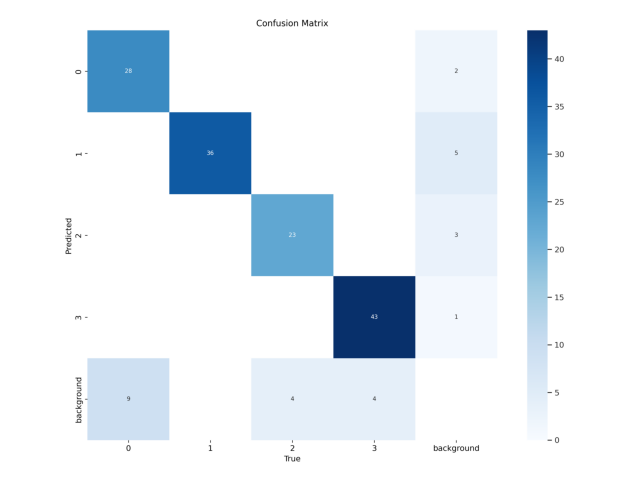

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Path to your image (change this to an actual image from your dataset)
image_path = "/content/runs/detect/train/confusion_matrix.png"

# Read and display the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB (for correct colors in Matplotlib)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")  # Hide axis
plt.show()


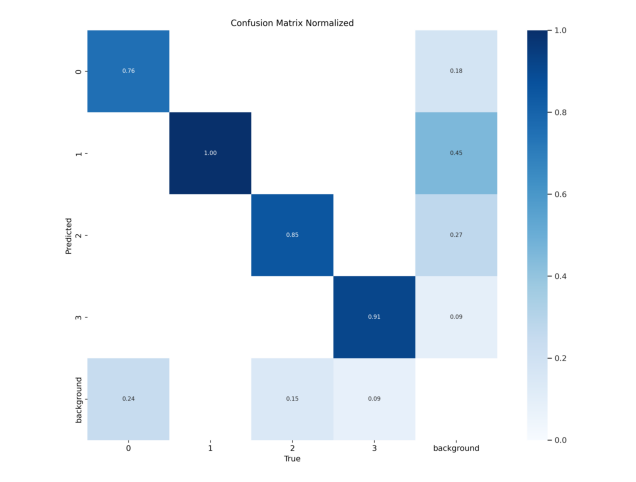

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Path to your image (change this to an actual image from your dataset)
image_path = "/content/runs/detect/train/confusion_matrix_normalized.png"

# Read and display the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB (for correct colors in Matplotlib)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")  # Hide axis
plt.show()


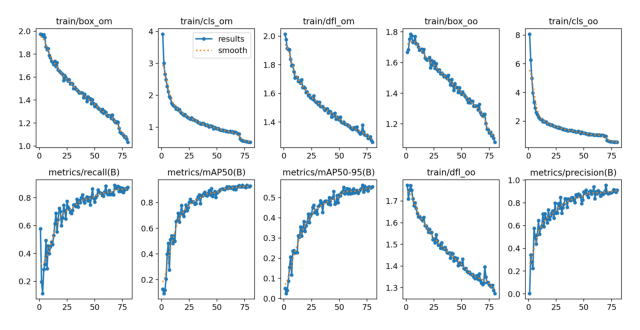

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Path to your image (change this to an actual image from your dataset)
image_path = "/content/runs/detect/train/results.png"

# Read and display the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB (for correct colors in Matplotlib)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")  # Hide axis
plt.show()


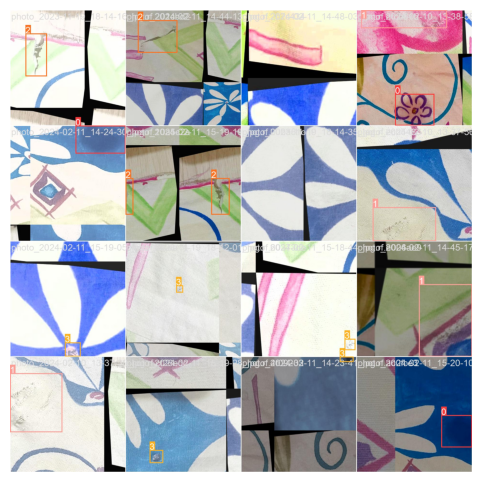

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Path to your image (change this to an actual image from your dataset)
image_path = "/content/runs/detect/train/train_batch1.jpg"

# Read and display the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB (for correct colors in Matplotlib)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")  # Hide axis
plt.show()


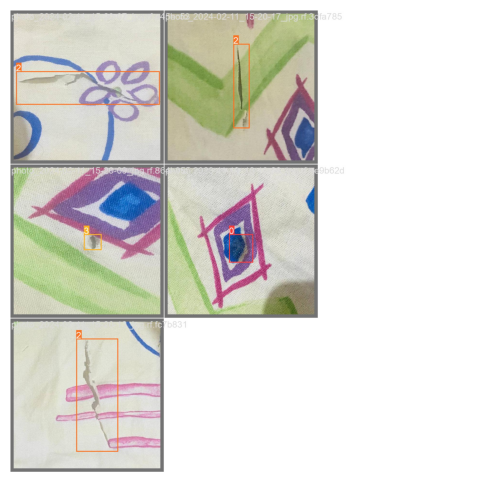

In [ ]:
import cv2
import matplotlib.pyplot as plt

# Path to your image (change this to an actual image from your dataset)
image_path = "/content/runs/detect/train/val_batch2_labels.jpg"

# Read and display the image
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert from BGR to RGB (for correct colors in Matplotlib)

plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")  # Hide axis
plt.show()


In [ ]:
import re

# Sample YOLO output
yolo_output = """
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% 3/3 [00:01<00:00,  1.56it/s]
                   all        133        147      0.889       0.88      0.923      0.562
"""

# Extract mAP@50 using regex
match = re.search(r"all\s+\d+\s+\d+\s+[\d.]+\s+[\d.]+\s+([\d.]+)", yolo_output)
if match:
    accuracy = float(match.group(1)) * 100
    print(f"🎯 Model Accuracy: {accuracy:.1f}%")
else:
    print("Accuracy not found.")


🎯 Model Accuracy: 92.3%
